c:\Users\analice\Documents\TCC\notebooks
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10237 entries, 0 to 10236
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   file_path                                    10237 non-null  object 
 1   image_path                                   10237 non-null  object 
 2   AccessionNumber                              0 non-null      float64
 3   BitsAllocated                                10237 non-null  int64  
 4   BitsStored                                   10237 non-null  int64  
 5   BodyPartExamined                             10237 non-null  object 
 6   Columns                                      10237 non-null  int64  
 7   ContentDate                                  10237 non-null  int64  
 8   ContentTime                                  10237 non-null  float64
 9   ConversionType                 

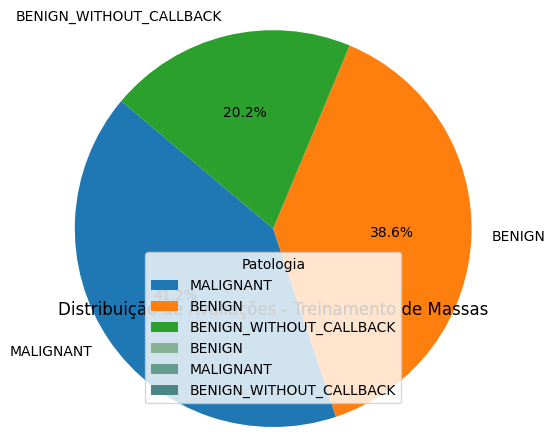

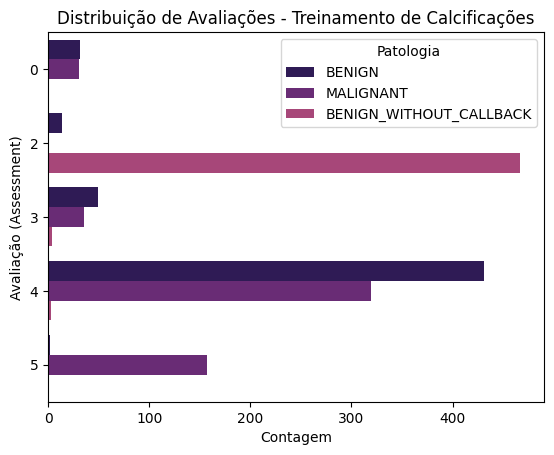

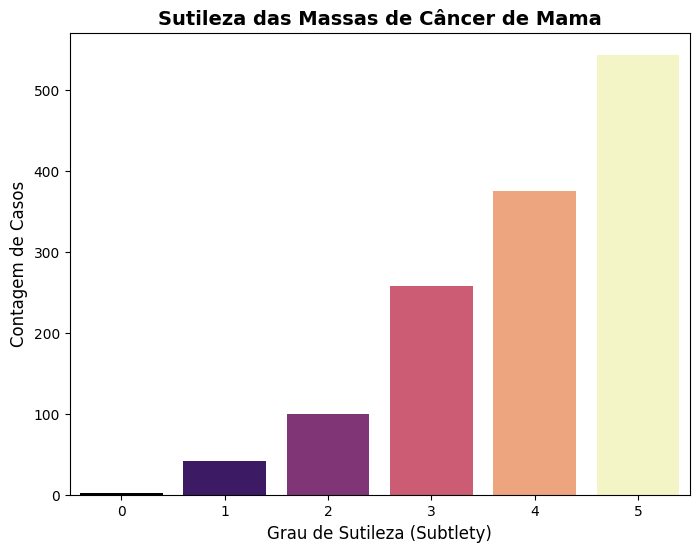

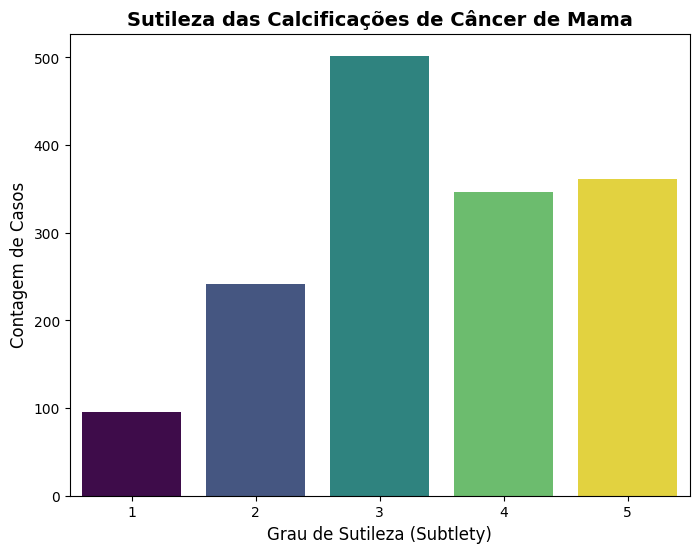

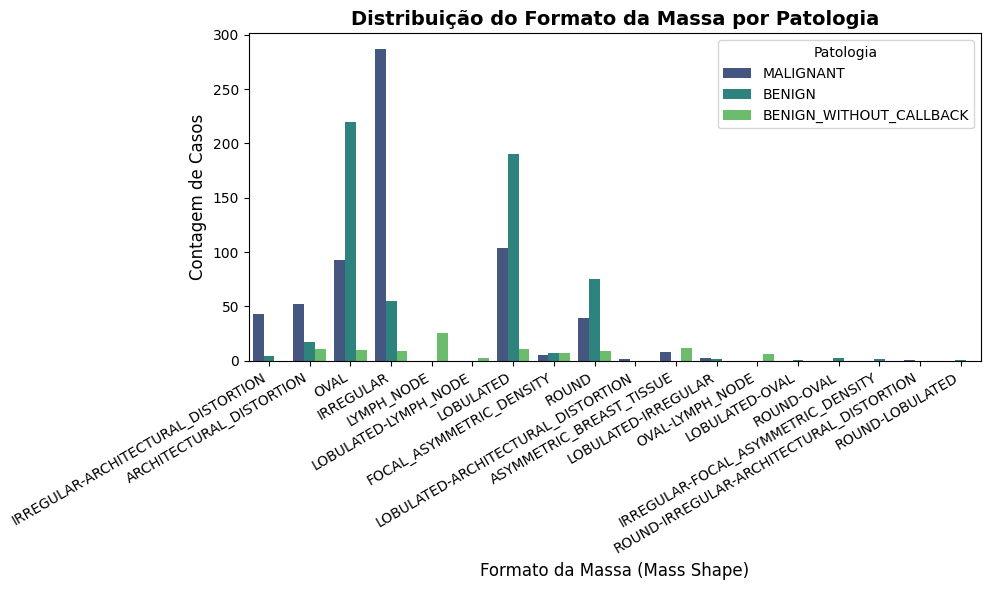

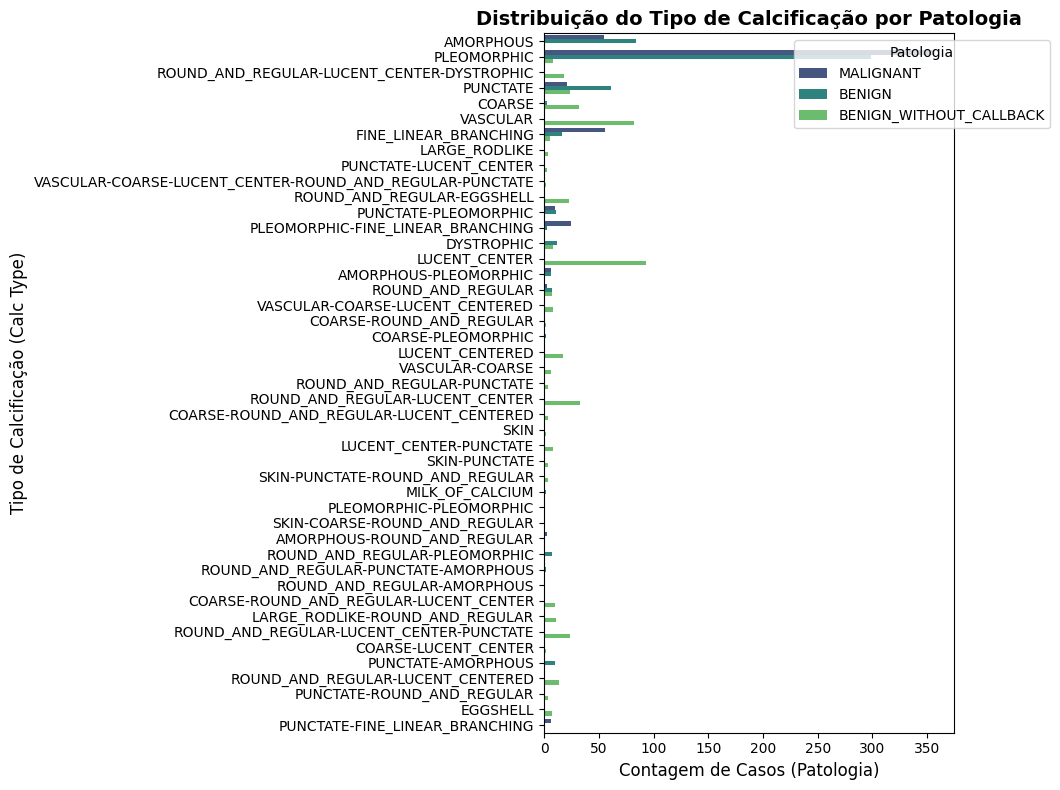

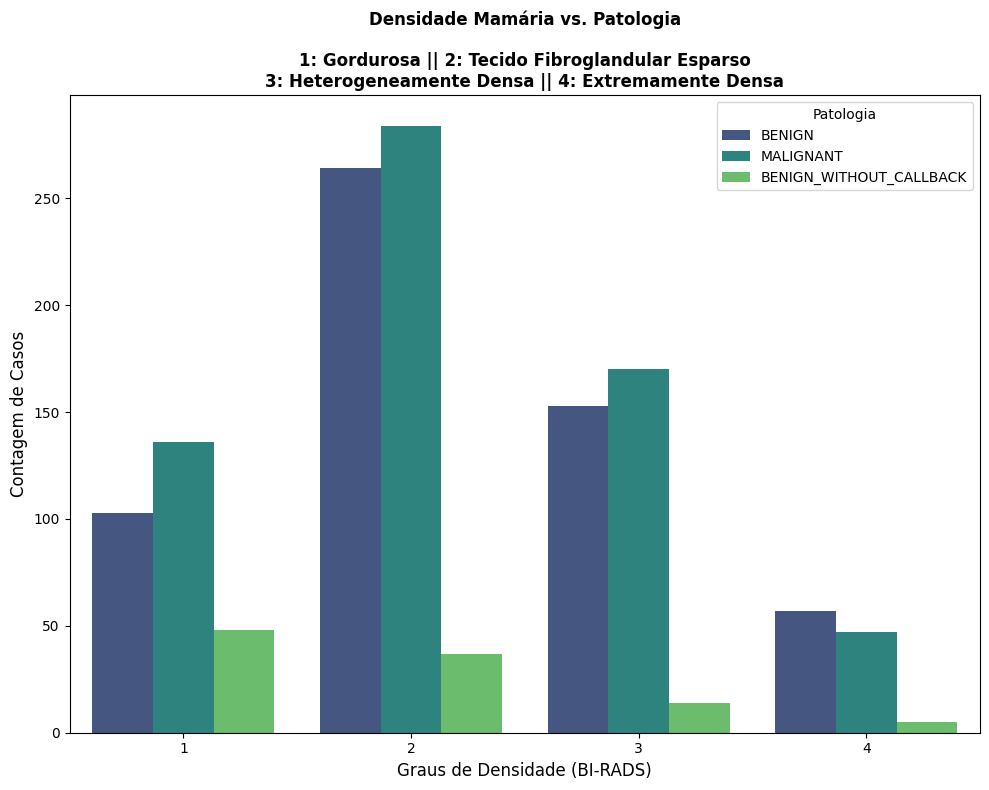

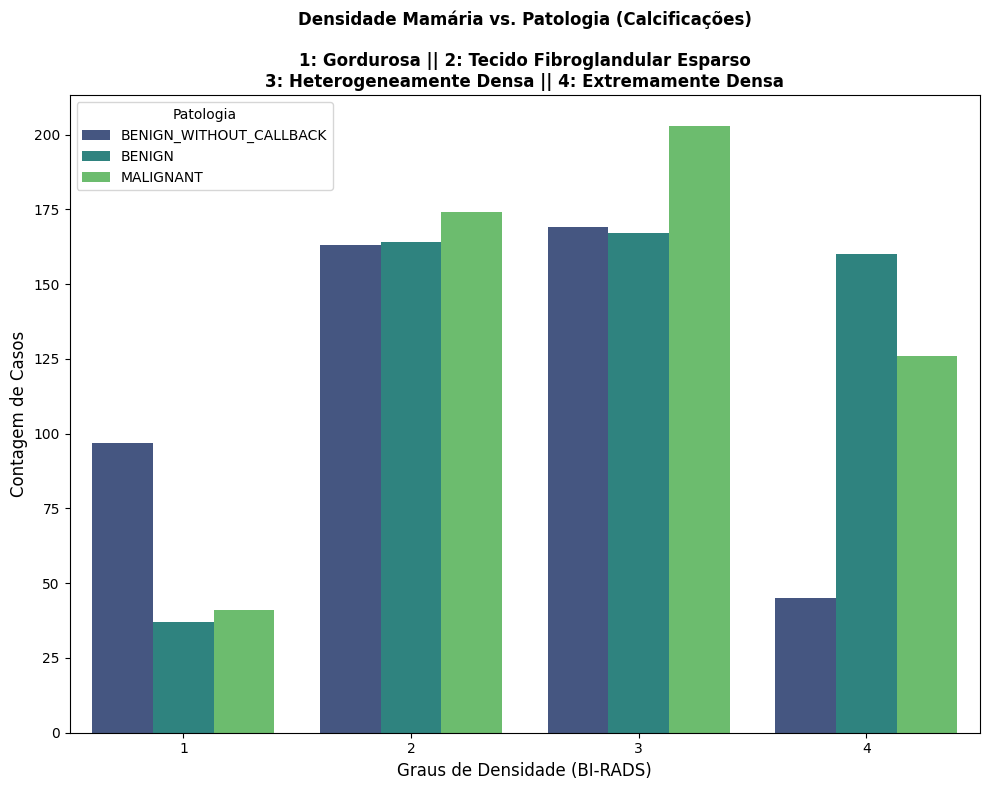

--- DATASET DE TREINAMENTO (MASSAS) ---

1. Mamografias Completas (Full Mammograms):


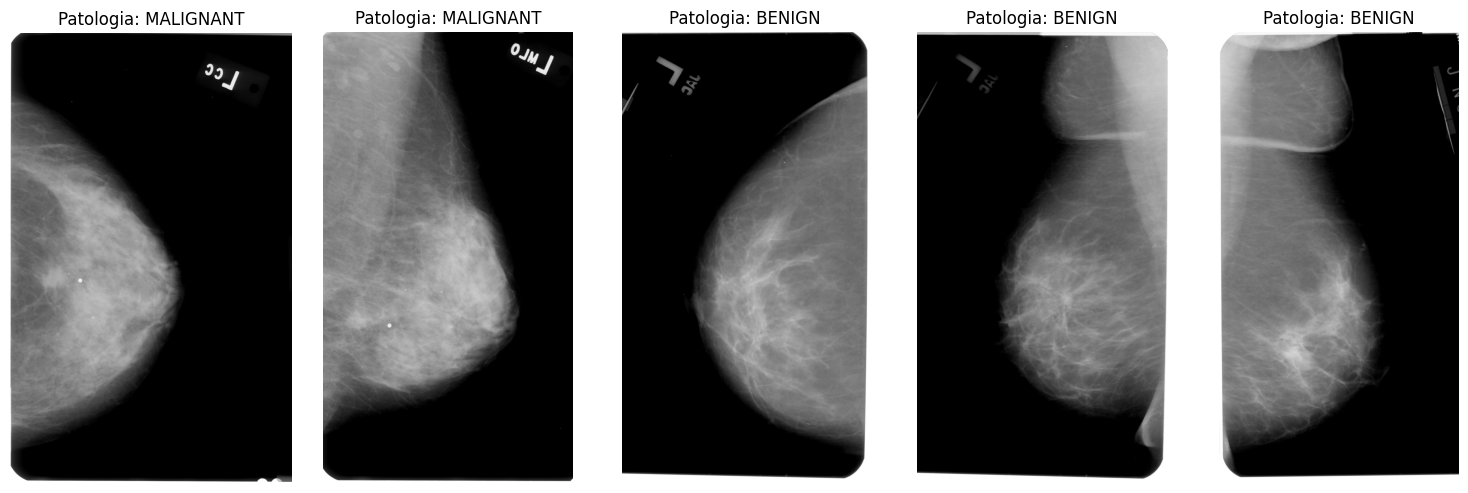


2. Recortes das Lesões (Cropped Images):


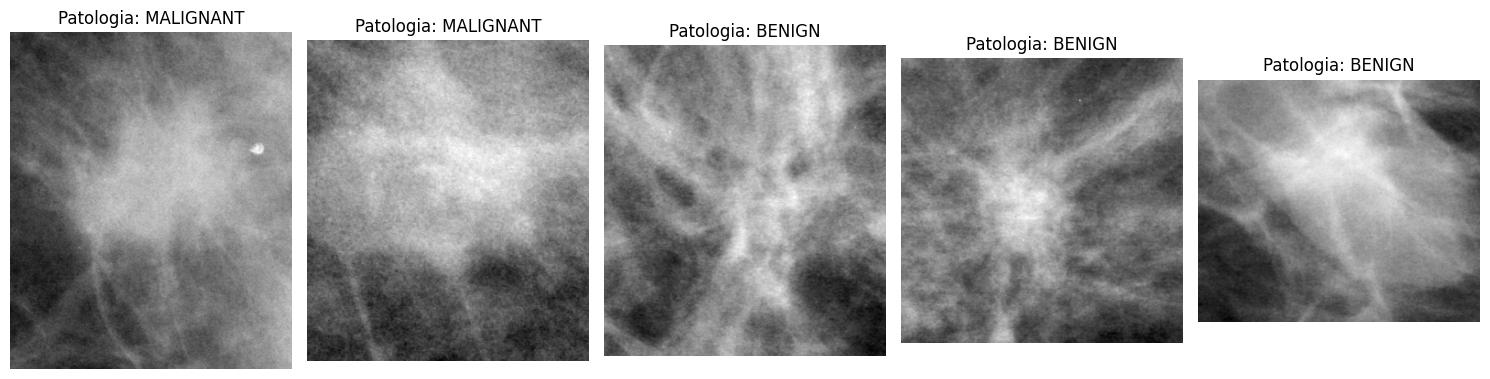


3. Máscaras da Região de Interesse (ROI Masks):


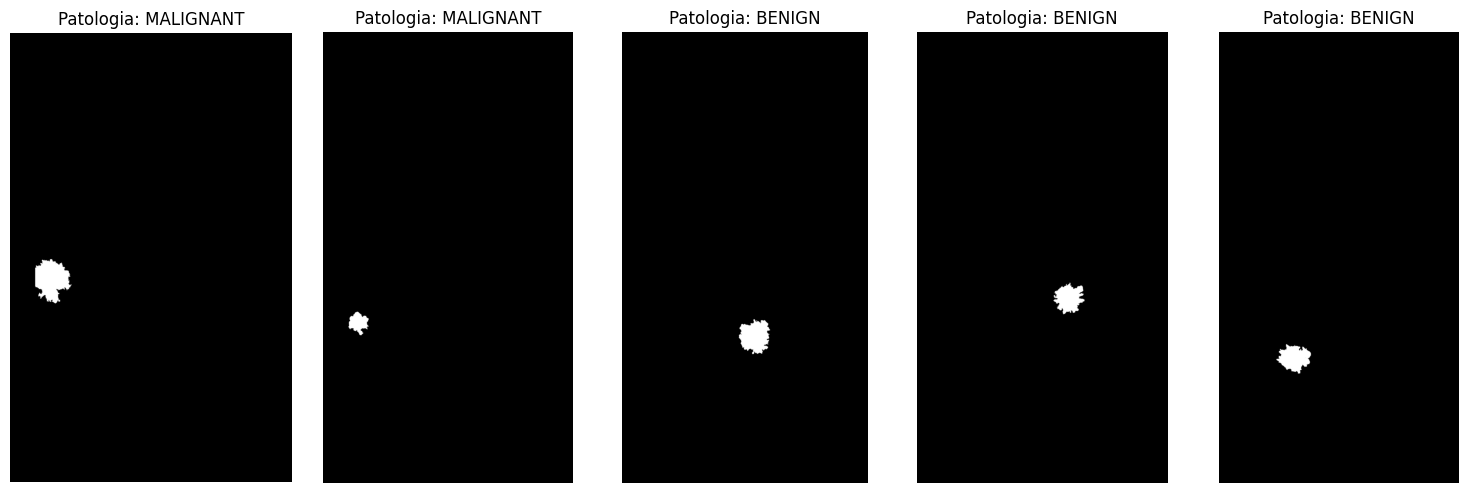

Mass Training Dataset


Full Mammograms:

C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/1-207.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/1-250.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/1-056.jpg


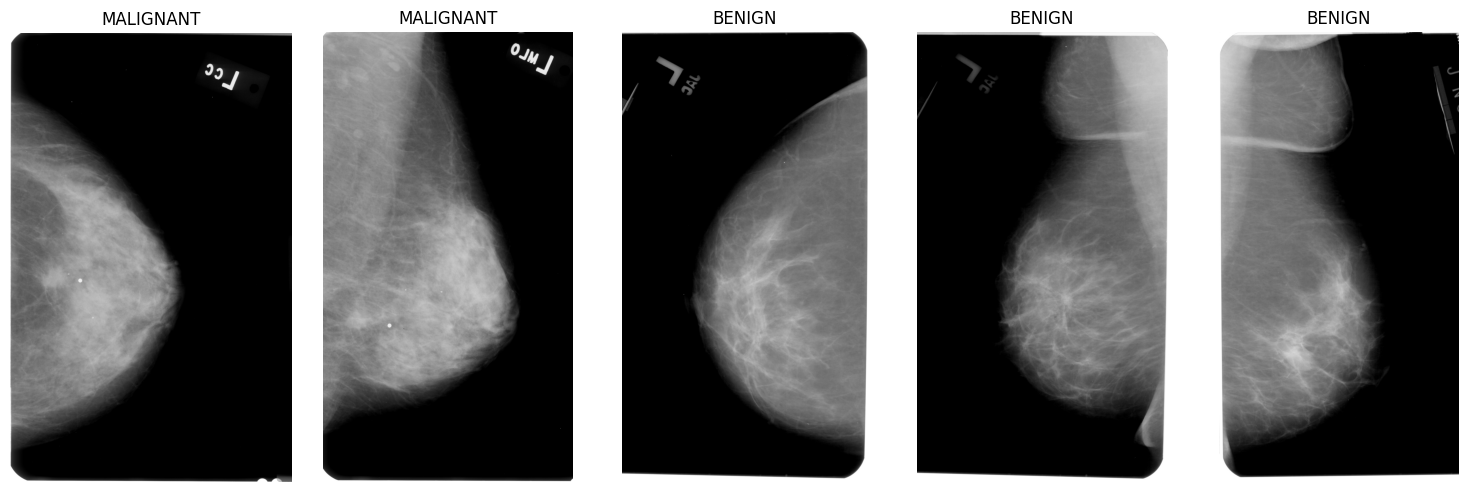

Cropped Mammograms:

C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/2-244.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/1-182.jpg


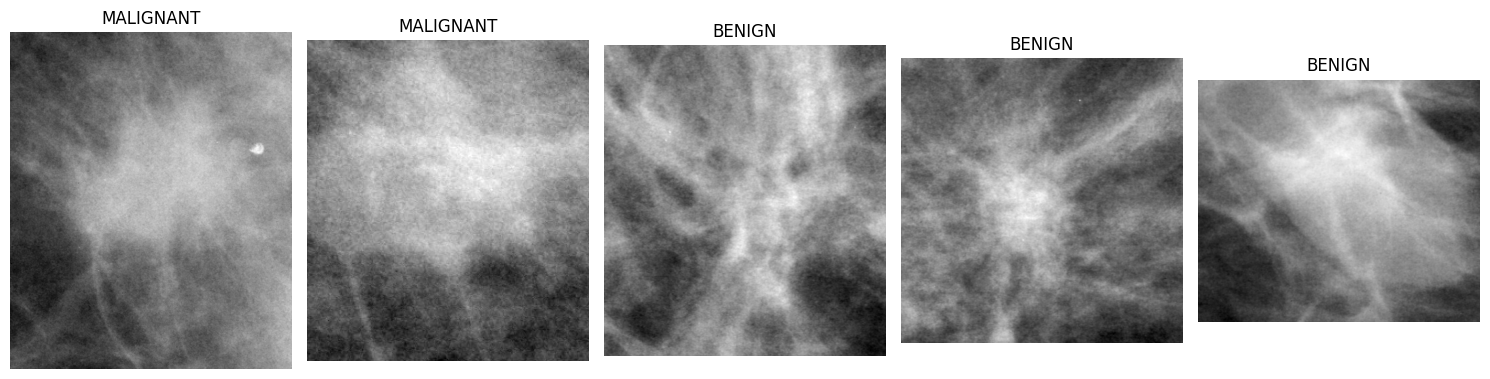

ROI Images:

C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/1-250.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/2-288.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/1-296.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/1-245.jpg
C:/Users/analice/Documents/TCC/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/2-183.jpg


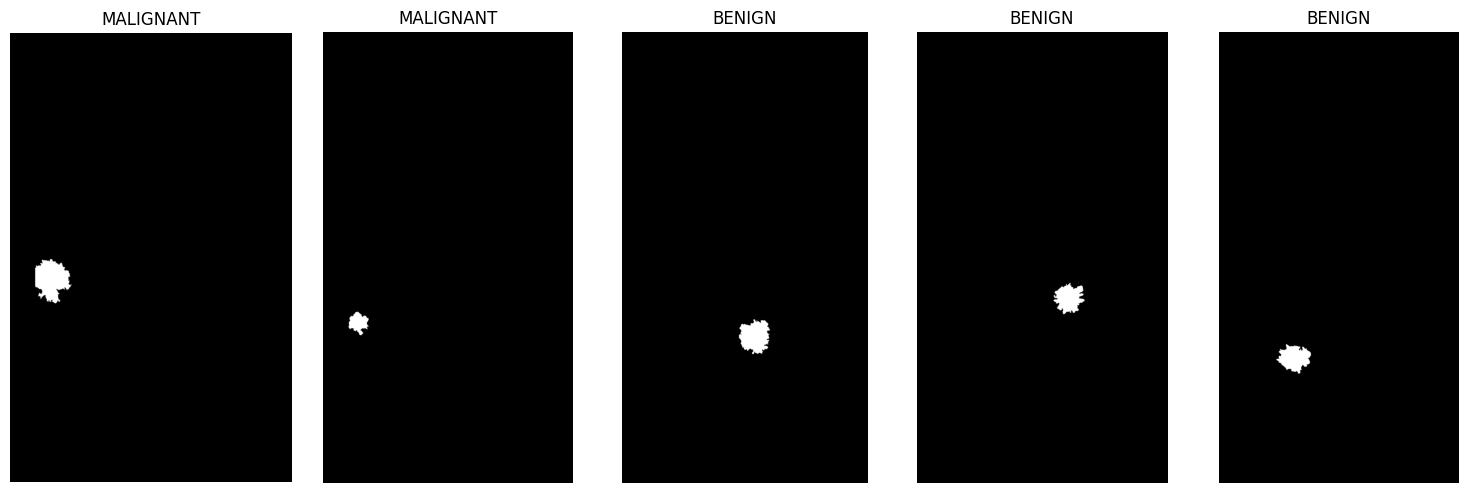

--- DATASET DE TREINAMENTO (CALCIFICAÇÕES) ---

1. Mamografias Completas (Full Mammograms):


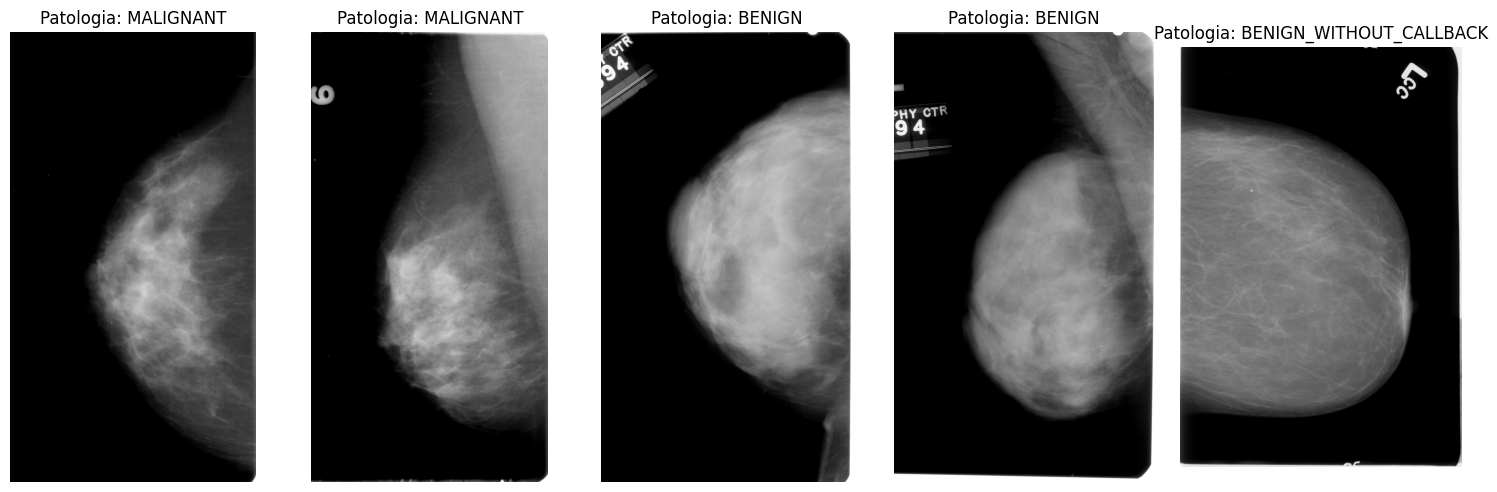


2. Recortes das Calcificações (Cropped Images):


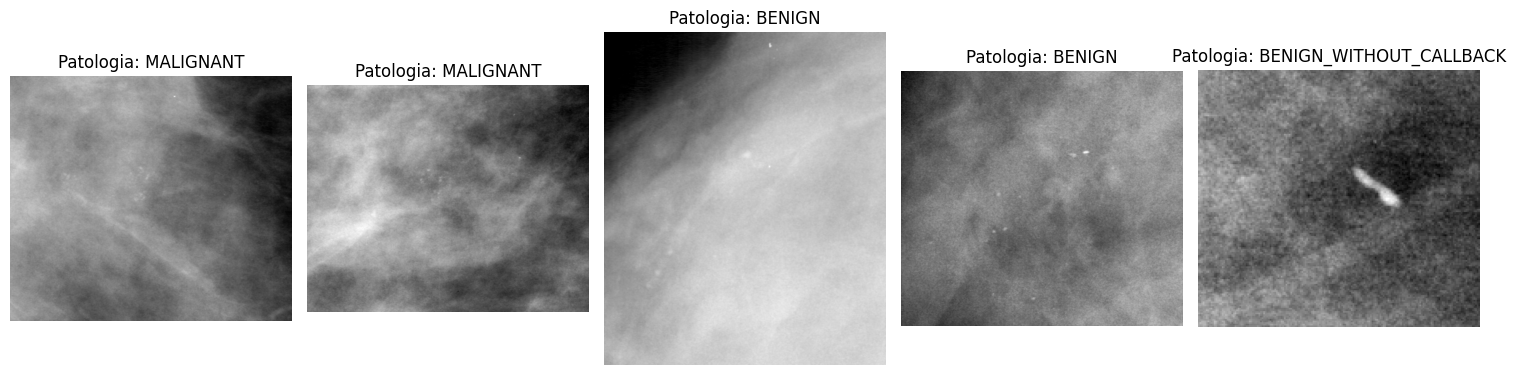


3. Máscaras de Segmentação (ROI Masks):


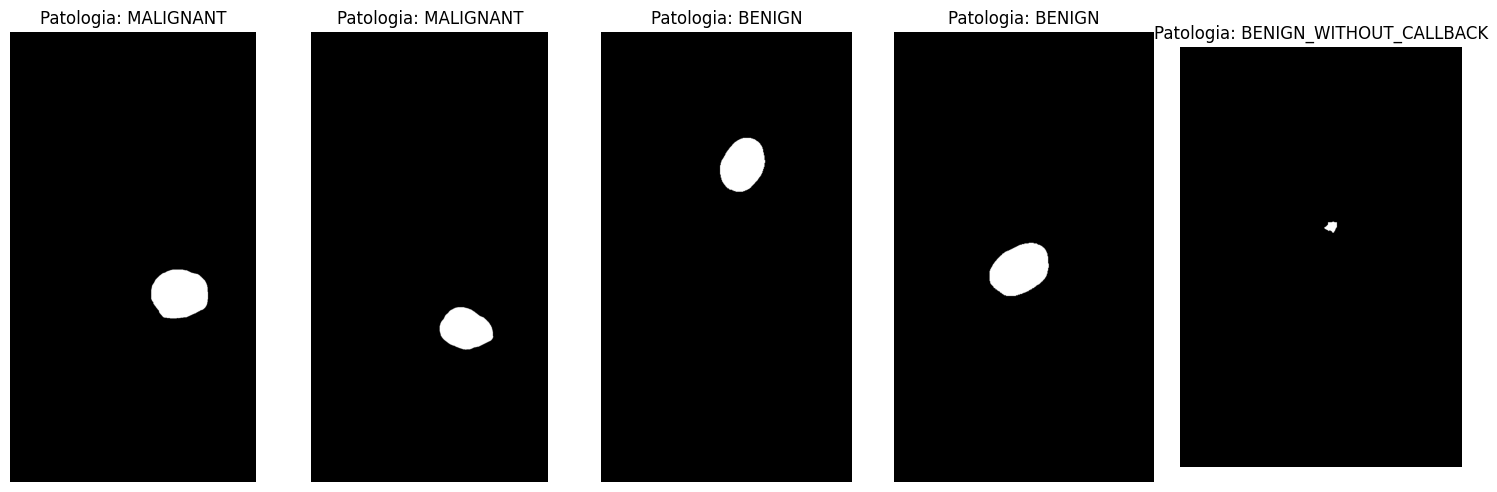

In [1]:
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import pre_processamento
from pre_processamento import mass_train, mass_test, calc_train, calc_test

In [2]:
# %% [1. PREPARAÇÃO DOS DADOS]
# Unificação e Mapeamento
mass_calc = pd.concat([mass_train, mass_test, calc_train, calc_test], axis=0).reset_index(drop=True)

class_mapper = {'MALIGNANT': 1, 'BENIGN': 0, 'BENIGN_WITHOUT_CALLBACK': 0}
mass_calc['labels'] = mass_calc['pathology'].map(class_mapper)
mass_calc = mass_calc.dropna(subset=['labels'])

# Configurações Globais
IMG_SIZE = 300
BATCH_SIZE = 16 # Ajuste conforme sua memória (GPU)
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# %% [2. FUNÇÃO DE PROCESSAMENTO (INTEGRANDO SUA LÓGICA)]
def process_mammogram(file_path, label):
    """
    Função para ser usada dentro do tf.data. 
    Mantém sua lógica de CLAHE e corte, mas otimizada para Tensores.
    """
    def _py_process(path):
        path_str = path.numpy().decode('utf-8')
        img = cv2.imread(path_str, cv2.IMREAD_GRAYSCALE)
        if img is None: return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        
        # Sua lógica de binarização e crop
        _, thresh = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            img = img[y:y+h, x:x+w]
        
        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
        
        # Resize e conversão RGB
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img_rgb.astype(np.float32)

    [image] = tf.py_function(_py_process, [file_path], [tf.float32])
    image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return image, label

In [4]:
# %% [3. DIVISÃO DO DATASET (ESTRATIFICADA)]
train_df, test_df = train_test_split(
    mass_calc, test_size=0.2, stratify=mass_calc['labels'], random_state=42
)
train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df['labels'], random_state=42
)

def create_tf_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['cropped_image_file_path'].values, df['labels'].values))
    ds = ds.map(process_mammogram, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_tf_dataset(train_df, training=True)
val_ds = create_tf_dataset(val_df)
test_ds = create_tf_dataset(test_df)

In [5]:
# %% [4. DATA AUGMENTATION & CLASS WEIGHTS]
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(train_df['labels']), y=train_df['labels']
)
class_weights = dict(enumerate(weights))

In [8]:
# %% [5. CONSTRUÇÃO DO MODELO EFFICIENTNET B3]

def build_mammography_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(preprocess_input)(x) # Normalização nativa da EfficientNet
    
    base_model = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False # Congelado inicialmente
    
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x) # 1 neurônio Sigmoid para Binary Class
    
    return models.Model(inputs, outputs, name="B3_Mammography_TCC"), base_model

model, base_model = build_mammography_model()

In [9]:
# %% [6. TREINAMENTO - FASE 1: WARM-UP]
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

print("--- Iniciando Fase 1: Treino da Cabeça de Classificação ---")
history1 = model.fit(
    train_ds, validation_data=val_ds, epochs=15, 
    class_weight=class_weights, callbacks=callbacks
)

--- Iniciando Fase 1: Treino da Cabeça de Classificação ---
Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 158s 953ms/step - accuracy: 0.5979 - auc: 0.6253 - loss: 1.1044 - val_accuracy: 0.6480 - val_auc: 0.6967 - val_loss: 0.6062 - learning_rate: 0.0010
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 145s 938ms/step - accuracy: 0.6062 - auc: 0.6510 - loss: 0.8895 - val_accuracy: 0.5781 - val_auc: 0.6479 - val_loss: 0.6479 - learning_rate: 0.0010
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 145s 937ms/step - accuracy: 0.6252 - auc: 0.6759 - loss: 0.7165 - val_accuracy: 0.6434 - val_auc: 0.6923 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 147s 954ms/step - accuracy: 0.6297 - auc: 0.6852 - loss: 0.6674 - val_accuracy: 0.6200 - val_auc: 0.6848 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 143s 927ms/step - accuracy: 0.6503 - auc: 0.7112 - loss: 0.6222 - val_accuracy: 0.6107 - val_auc: 0.7029 - val_loss: 0.6240 - learning_rate: 2.0000e

In [ ]:
# %% [7. TREINAMENTO - FASE 2: FINE-TUNING]
print("--- Iniciando Fase 2: Fine-Tuning do Topo da B3 ---")

# Descongelar as últimas 30 camadas (exceto BatchNormalization)
base_model.trainable = True

for layer in base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompilar com LR baixo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history2 = model.fit(
    train_ds, validation_data=val_ds, epochs=20, 
    class_weight=class_weights, callbacks=callbacks
)

# %% [8. AVALIAÇÃO FINAL NO TESTE INDEPENDENTE]
print("-" * 30)
results = model.evaluate(test_ds)
print(f"RESULTADOS NO TESTE INDEPENDENTE:")
print(f"Loss: {results[0]:.4f}")
print(f"Acurácia: {results[1]:.4f}")
print(f"AUC: {results[2]:.4f}")
print("-" * 30)

# Salvar o modelo final
model.save('modelo_mammography_tcc_final.h5')

--- Iniciando Fase 2: Fine-Tuning do Topo da B3 ---
Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.6680 - auc: 0.7417 - loss: 0.5915 - val_accuracy: 0.6713 - val_auc: 0.7396 - val_loss: 0.5830 - learning_rate: 1.0000e-05
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.6784 - auc: 0.7569 - loss: 0.5777 - val_accuracy: 0.6783 - val_auc: 0.7433 - val_loss: 0.5833 - learning_rate: 1.0000e-05
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.6849 - auc: 0.7570 - loss: 0.5793 - val_accuracy: 0.6737 - val_auc: 0.7473 - val_loss: 0.5819 - learning_rate: 1.0000e-05
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.6920 - auc: 0.7717 - loss: 0.5658 - val_accuracy: 0.6760 - val_auc: 0.7451 - val_loss: 0.5804 - learning_rate: 2.0000e-06
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.6816 - auc: 0.7626 - loss: 0.5697 - val_accuracy: 0.6807 - val_auc: 0.7455 - val_loss: 0.5795 - learning_rate: 2.0000e-06
---

RESULTADOS NO TESTE INDEPENDENTE:
Loss: 0.5530
Acurácia: 0.7045
AUC: 0.7693
------------------------------
